# 01 — Аудит и подготовка изображений шлифов

Notebook не изменяет исходные изображения. Он строит каталог данных, проверяет читаемость, находит точные дубли и конфликты меток, связывает изображения с разметкой областей оталькования и создаёт воспроизводимые ML-сплиты. Результаты сохраняются в `data/processed/`.

> Важно: папка `Области оталькования` содержит изображения с цветной экспертной линией, а не готовые бинарные маски. Они учитываются как аннотации, но преобразование линий в маски требует отдельной проверки смысла разметки.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import hashlib, json, random, re, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFile

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
ImageFile.LOAD_TRUNCATED_IMAGES = False

def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data').is_dir() and (candidate / 'requirements.txt').exists():
            return candidate
    raise FileNotFoundError('Не найден корень проекта с data/ и requirements.txt')

ROOT = find_project_root()
DATA_DIR = ROOT / 'data'
OUT_DIR = DATA_DIR / 'processed'
OUT_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
print('Project:', ROOT)
print('Data:', DATA_DIR)

Project: D:\projects\Ore-slice-classifier
Data: D:\projects\Ore-slice-classifier\data


## 1. Каталогизация и нормализация меток

Метка выводится из структуры папок. `тонкие` и `Труднообогатимые руды` объединяются в класс `difficult`; `рядовые` — `ordinary`; `оталькованные` — `talc`. Панорамы оставляем как `unlabeled`.

In [2]:
def infer_role_and_label(relative_path):
    text = relative_path.as_posix().casefold()
    if 'области оталькования' in text:
        return 'annotation_overlay', 'talc'
    if 'панорам' in text:
        return 'panorama', 'unlabeled'
    if 'оталькован' in text:
        return 'image', 'talc'
    if 'труднообогат' in text or 'тонкие' in text:
        return 'image', 'difficult'
    if 'рядов' in text:
        return 'image', 'ordinary'
    return 'unknown', 'unlabeled'

def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(chunk_size), b''):
            digest.update(chunk)
    return digest.hexdigest()

records = []
for path in sorted(DATA_DIR.rglob('*')):
    if not path.is_file() or path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    # Не включаем результаты предыдущего запуска в новый аудит.
    if OUT_DIR in path.parents:
        continue
    rel = path.relative_to(DATA_DIR)
    role, label = infer_role_and_label(rel)
    row = dict(
        path=path.relative_to(ROOT).as_posix(), filename=path.name,
        suffix=path.suffix.lower(), source_dir=rel.parent.as_posix(),
        role=role, label=label, bytes=path.stat().st_size,
        width=np.nan, height=np.nan, mode=None, readable=False, error=None,
    )
    try:
        # MAX_IMAGE_PIXELS отключаем только для чтения заголовка: полное изображение здесь не декодируется.
        old_limit = Image.MAX_IMAGE_PIXELS
        Image.MAX_IMAGE_PIXELS = None
        with Image.open(path) as image:
            row.update(width=image.width, height=image.height, mode=image.mode, readable=True)
        Image.MAX_IMAGE_PIXELS = old_limit
    except Exception as exc:
        Image.MAX_IMAGE_PIXELS = old_limit
        row['error'] = f'{type(exc).__name__}: {exc}'
    row['sha256'] = sha256_file(path)
    records.append(row)

catalog = pd.DataFrame(records)
catalog['megapixels'] = catalog.width * catalog.height / 1e6
display(catalog.groupby(['role', 'label'], dropna=False).size().rename('count').to_frame())
display(catalog.groupby('suffix').size().rename('count').to_frame())
print(f'Всего: {len(catalog)}; нечитаемых: {(~catalog.readable).sum()}')

count
role               label           
annotation_overlay talc          42
image              difficult    486
                   ordinary     565
                   talc         129
panorama           unlabeled     14

,count
suffix,
.bmp,1
.jpg,1235


Всего: 1236; нечитаемых: 0


## 2. Контроль качества, дубли и конфликтующие метки

Точный SHA-256 находит побайтово одинаковые изображения. Все копии получают общий `duplicate_group`; конфликтом считается группа с несколькими метками. Конфликтующие группы нельзя автоматически использовать для обучения.

In [3]:
hash_counts = catalog.groupby('sha256').size()
duplicate_hashes = set(hash_counts[hash_counts > 1].index)
catalog['is_exact_duplicate'] = catalog.sha256.isin(duplicate_hashes)
catalog['duplicate_group'] = catalog.sha256.str[:16]

image_rows = catalog[catalog.role == 'image']
label_counts_per_hash = image_rows.groupby('sha256').label.nunique()
conflicting_hashes = set(label_counts_per_hash[label_counts_per_hash > 1].index)
catalog['label_conflict'] = catalog.sha256.isin(conflicting_hashes)
catalog['too_large_for_full_decode'] = catalog.megapixels > 100
catalog['needs_review'] = (~catalog.readable) | catalog.label_conflict

print('Групп точных дублей:', len(duplicate_hashes))
print('Лишних копий:', int(sum(hash_counts[hash_counts > 1] - 1)))
print('Групп с конфликтом меток:', len(conflicting_hashes))
if conflicting_hashes:
    display(catalog[catalog.sha256.isin(conflicting_hashes)][['path', 'label', 'sha256']].sort_values('sha256'))
display(catalog.nlargest(15, 'megapixels')[['path', 'width', 'height', 'megapixels', 'role']])

Групп точных дублей: 57
Лишних копий: 57
Групп с конфликтом меток: 24


,path,label,sha256
1187,data/Фото руд по сортам. ч2/тонкие/DSCN4483.JPG,difficult,0e68b62613758df09fb67bc672e98ab0d9088228f650a4...
773,data/Фото руд по сортам. ч2/рядовые/DSCN4483.JPG,ordinary,0e68b62613758df09fb67bc672e98ab0d9088228f650a4...
1172,data/Фото руд по сортам. ч2/тонкие/DSCN4407.JPG,difficult,2762f5d22ce6a9f8508922adc3891db9d1f2fa83c3a602...
754,data/Фото руд по сортам. ч2/рядовые/DSCN4407.JPG,ordinary,2762f5d22ce6a9f8508922adc3891db9d1f2fa83c3a602...
729,data/Фото руд по сортам. ч2/рядовые/DSCN4243.JPG,ordinary,2c8516c22965563ae68419340b385ff066a124f1c78ddf...
309,data/Фото руд по сортам. ч2/оталькованные/DSCN...,talc,2c8516c22965563ae68419340b385ff066a124f1c78ddf...
1184,data/Фото руд по сортам. ч2/тонкие/DSCN4467.JPG,difficult,2d66d3471afc06042463f35e70c7e06af7a44f17736291...
769,data/Фото руд по сортам. ч2/рядовые/DSCN4467.JPG,ordinary,2d66d3471afc06042463f35e70c7e06af7a44f17736291...
1136,data/Фото руд по сортам. ч2/тонкие/DSCN3515.JPG,difficult,479abed31f67328e6d155ee087bdf90c77509047273a0e...
715,data/Фото руд по сортам. ч2/рядовые/DSCN3515.JPG,ordinary,479abed31f67328e6d155ee087bdf90c77509047273a0e...


,path,width,height,megapixels,role
6,data/Панорамы/16.jpg,27025,21227,573.659675,panorama
10,data/Панорамы/6.jpg,22166,16515,366.071490,panorama
11,data/Панорамы/7.jpg,22166,16515,366.071490,panorama
9,data/Панорамы/5.jpg,21841,16225,354.370225,panorama
12,data/Панорамы/8.jpg,21662,15879,343.970898,panorama
4,data/Панорамы/14.jpg,20642,14585,301.063570,panorama
7,data/Панорамы/17.jpg,18495,13730,253.936350,panorama
13,data/Панорамы/9.jpg,18317,12151,222.569867,panorama
0,data/Панорамы/10.jpg,14999,10391,155.854609,panorama
5,data/Панорамы/15.jpg,16439,9347,153.655333,panorama


## 3. Связь исходников с цветной разметкой талька

Файлы сопоставляются по имени внутри части 1. Дополнительно проверяется совпадение размеров.

In [4]:
def normalized_stem(filename):
    return re.sub(r'\s+', ' ', Path(filename).stem.strip().casefold()).replace('х', 'x')

annotations = catalog[catalog.role == 'annotation_overlay'].copy()
talc_sources = catalog[(catalog.role == 'image') & (catalog.label == 'talc')].copy()
annotations['match_key'] = annotations.filename.map(normalized_stem)
talc_sources['match_key'] = talc_sources.filename.map(normalized_stem)
pairs = talc_sources.merge(
    annotations[['match_key', 'path', 'width', 'height']], on='match_key', how='left',
    suffixes=('_image', '_annotation')
)
pairs['dimensions_match'] = (pairs.width_image == pairs.width_annotation) & (pairs.height_image == pairs.height_annotation)
pairs = pairs.rename(columns={'path_image': 'image_path', 'path_annotation': 'annotation_path'})
print('Аннотаций:', len(annotations))
print('Сопоставленных пар:', pairs.annotation_path.notna().sum())
print('Пар с одинаковым размером:', pairs.dimensions_match.sum())
display(pairs[['image_path', 'annotation_path', 'dimensions_match']].head())

Аннотаций: 42
Сопоставленных пар: 44
Пар с одинаковым размером: 44


,image_path,annotation_path,dimensions_match
0,data/Фото руд по сортам. ч1/Оталькованные руды...,data/Фото руд по сортам. ч1/Оталькованные руды...,True
1,data/Фото руд по сортам. ч1/Оталькованные руды...,data/Фото руд по сортам. ч1/Оталькованные руды...,True
2,data/Фото руд по сортам. ч1/Оталькованные руды...,data/Фото руд по сортам. ч1/Оталькованные руды...,True
3,data/Фото руд по сортам. ч1/Оталькованные руды...,data/Фото руд по сортам. ч1/Оталькованные руды...,True
4,data/Фото руд по сортам. ч1/Оталькованные руды...,data/Фото руд по сортам. ч1/Оталькованные руды...,True


## 4. Быстрый визуальный EDA

Превью строятся только для обычных микрофотографий. Гигапиксельные панорамы намеренно не декодируются целиком.

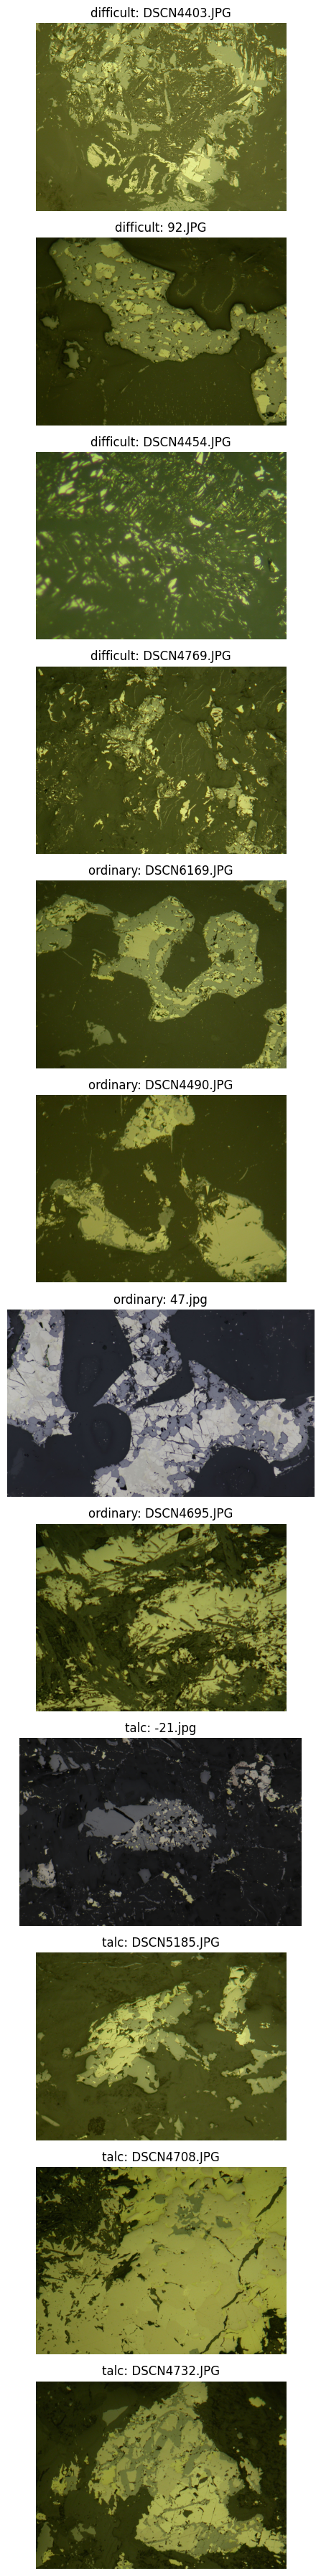

In [5]:
def show_samples(frame, n_per_class=4):
    valid = frame[frame.readable & ~frame.too_large_for_full_decode]
    sampled = pd.concat([
        group.sample(min(n_per_class, len(group)), random_state=SEED)
        for _, group in valid.groupby('label')
    ], ignore_index=True)
    fig, axes = plt.subplots(len(sampled), 1, figsize=(8, 3 * len(sampled)), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), sampled.iterrows()):
        with Image.open(ROOT / row.path) as image:
            image.thumbnail((900, 600))
            ax.imshow(image)
        ax.set_title(f'{row.label}: {row.filename}')
        ax.axis('off')
    plt.tight_layout()

show_samples(catalog[catalog.role == 'image'])

## 5. Group-aware train/validation/test split

Разбиение выполняется по группам SHA-256, поэтому точные дубли остаются в одном сплите. Из каждой группы сохраняется один канонический файл. Конфликтующие метки, нечитаемые файлы, аннотации и панорамы исключаются. Пропорции: 70/15/15 по каждому классу.

> Это базовая защита от leakage. Имена вроде `100.JPG` и `100_.jpg` могут быть разными полями зрения одного шлифа; перед финальным обучением желательно получить идентификатор физического образца и делать split именно по нему.

In [6]:
eligible = catalog[(catalog.role == 'image') & catalog.readable & ~catalog.label_conflict].copy()
eligible = eligible.sort_values('path').drop_duplicates('sha256', keep='first')
eligible['split'] = None

rng = np.random.default_rng(SEED)
for label, indexes in eligible.groupby('label').groups.items():
    indexes = np.array(list(indexes))
    rng.shuffle(indexes)
    n = len(indexes)
    n_train = int(round(n * 0.70))
    n_val = int(round(n * 0.15))
    eligible.loc[indexes[:n_train], 'split'] = 'train'
    eligible.loc[indexes[n_train:n_train+n_val], 'split'] = 'val'
    eligible.loc[indexes[n_train+n_val:], 'split'] = 'test'

assert eligible.split.notna().all()
assert eligible.groupby('sha256').split.nunique().max() == 1
display(pd.crosstab(eligible.label, eligible.split, margins=True))

split,test,train,val,All
label,,,,
difficult,68,321,69,458
ordinary,79,369,79,527
talc,18,80,17,115
All,165,770,165,1100


## 6. Экспорт манифестов

CSV используют UTF-8 с BOM (`utf-8-sig`), чтобы русские пути корректно открывались в Excel. Изображения не копируются: модель должна читать их по столбцу `path`.

In [7]:
catalog_path = OUT_DIR / 'image_catalog.csv'
manifest_path = OUT_DIR / 'classification_manifest.csv'
pairs_path = OUT_DIR / 'talc_annotation_pairs.csv'
review_path = OUT_DIR / 'manual_review.csv'
summary_path = OUT_DIR / 'audit_summary.json'

catalog.to_csv(catalog_path, index=False, encoding='utf-8-sig')
eligible[['path', 'label', 'split', 'width', 'height', 'megapixels', 'sha256']]
eligible.to_csv(manifest_path, index=False, encoding='utf-8-sig')
pairs[['image_path', 'annotation_path', 'dimensions_match']].to_csv(pairs_path, index=False, encoding='utf-8-sig')
catalog[catalog.needs_review].to_csv(review_path, index=False, encoding='utf-8-sig')

summary = {
    'seed': SEED, 'total_images': int(len(catalog)),
    'classification_images': int((catalog.role == 'image').sum()),
    'annotation_overlays': int((catalog.role == 'annotation_overlay').sum()),
    'panoramas': int((catalog.role == 'panorama').sum()),
    'unreadable': int((~catalog.readable).sum()),
    'exact_duplicate_groups': int(len(duplicate_hashes)),
    'extra_duplicate_files': int(sum(hash_counts[hash_counts > 1] - 1)),
    'conflicting_label_groups': int(len(conflicting_hashes)),
    'training_manifest_rows': int(len(eligible)),
    'split_counts': eligible.groupby(['split', 'label']).size().map(int).to_dict(),
}
# JSON не поддерживает tuple-ключи.
summary['split_counts'] = {f'{split}/{label}': count for (split, label), count in summary['split_counts'].items()}
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print(json.dumps(summary, ensure_ascii=False, indent=2))
print('Сохранено в:', OUT_DIR)

{
  "seed": 42,
  "total_images": 1236,
  "classification_images": 1180,
  "annotation_overlays": 42,
  "panoramas": 14,
  "unreadable": 0,
  "exact_duplicate_groups": 57,
  "extra_duplicate_files": 57,
  "conflicting_label_groups": 24,
  "training_manifest_rows": 1100,
  "split_counts": {
    "test/difficult": 68,
    "test/ordinary": 79,
    "test/talc": 18,
    "train/difficult": 321,
    "train/ordinary": 369,
    "train/talc": 80,
    "val/difficult": 69,
    "val/ordinary": 79,
    "val/talc": 17
  }
}
Сохранено в: D:\projects\Ore-slice-classifier\data\processed


## Что делать дальше

1. Просмотреть `manual_review.csv` и согласовать конфликтующие метки с геологом.
2. Уточнить, что означает цветная линия: граница области талька или штрих по самому тальку. Без этого нельзя честно вычислить бинарную маску и процент площади.
3. Получить идентификаторы физических шлифов/образцов и заменить файловый split на group split по образцу.
4. Для классификационного baseline обучать модель по `classification_manifest.csv`.
5. Панорамы обрабатывать тайлами с overlap, а не масштабировать целиком.